In [1]:
import pandas as pd


class PerformanceMetrics:
    """
    Calculates performance statistics from backtest results.
    """

    def __init__(self, results_df):
        self.df = results_df.copy()

        if self.df.empty:
            raise ValueError("Results DataFrame is empty.")

        self.df["portfolio_value"] = pd.to_numeric(
            self.df["portfolio_value"],
            errors="coerce"
        )

        self.df["total_pnl"] = pd.to_numeric(
            self.df["total_pnl"],
            errors="coerce"
        )

    # =========================================================
    # TOTAL RETURN
    # =========================================================

    def total_return(self):

        first = self.df["portfolio_value"].iloc[0]
        last = self.df["portfolio_value"].iloc[-1]

        return ((last - first) / first) * 100

    # =========================================================
    # MAXIMUM DRAWDOWN
    # =========================================================

    def max_drawdown(self):

        values = self.df["portfolio_value"]

        running_max = values.cummax()

        drawdown = (
            (values - running_max)
            / running_max
            * 100
        )

        return drawdown.min()

    # =========================================================
    # TRADE COUNT
    # =========================================================

    def trade_count(self):

        return self.df["trade"].notna().sum()

    # =========================================================
    # FINAL P&L
    # =========================================================

    def final_pnl(self):

        return self.df["total_pnl"].iloc[-1]

    # =========================================================
    # SUMMARY
    # =========================================================

    def summary(self):

        return {
            "total_return_pct": round(
                self.total_return(), 2
            ),

            "max_drawdown_pct": round(
                self.max_drawdown(), 2
            ),

            "trade_count": int(
                self.trade_count()
            ),

            "final_pnl": round(
                float(self.final_pnl()), 2
            ),

            "final_portfolio_value": round(
                float(
                    self.df["portfolio_value"].iloc[-1]
                ),
                2
            )
        }

In [6]:
from backtester import Backtester
from config_loader import (
    get_google_sheet_config,
    convert_config_values
)

rows = get_google_sheet_config()

config = convert_config_values(rows)

config

from trading_agent import TradingAgent

agent = TradingAgent(config)

backtester = Backtester(agent)
df = pd.read_csv('../data/btc_indicators.csv')

df = df.rename(
    columns={
        "close": "price", "rsi_14": "rsi", "atr_14": "atr"
    }
)
test_df = df.tail(50).copy()
results = backtester.run(test_df)

metrics = PerformanceMetrics(results)

print(metrics.summary())

DCA BUY executed: $500.00 at $78,115.16
{'total_return_pct': np.float64(-0.04), 'max_drawdown_pct': -0.12, 'trade_count': 1, 'final_pnl': -4.53, 'final_portfolio_value': 9995.47}


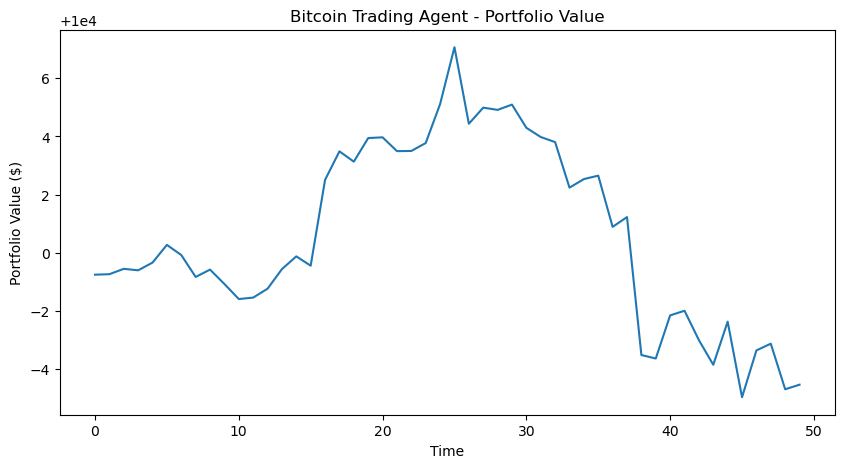

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    results["portfolio_value"]
)

plt.title("Bitcoin Trading Agent - Portfolio Value")
plt.xlabel("Time")
plt.ylabel("Portfolio Value ($)")

plt.show()